## Data Loading and Overview

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

In [ ]:
# let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PythonEDA/Automobile.csv')
# df = pd.read_csv('/location on your computer/Automobile (1).csv')

In [ ]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,number_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,168,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,168,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,168,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [ ]:
df.shape

(201, 26)

- The data has 201 rows and 26 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   symboling            201 non-null    int64  
 1   normalized_losses    201 non-null    int64  
 2   make                 201 non-null    object 
 3   fuel_type            201 non-null    object 
 4   aspiration           201 non-null    object 
 5   number_of_doors      201 non-null    object 
 6   body_style           201 non-null    object 
 7   drive_wheels         201 non-null    object 
 8   engine_location      201 non-null    object 
 9   wheel_base           201 non-null    float64
 10  length               201 non-null    float64
 11  width                201 non-null    float64
 12  height               201 non-null    float64
 13  curb_weight          201 non-null    int64  
 14  engine_type          201 non-null    object 
 15  number_of_cylinders  201 non-null    obj

- There are attributes of different types (*int*, *float*, *object*) in the data.

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,201.0,NaN,NaN,NaN,0.840796,1.254802,-2.0,0.0,1.0,2.0,3.0
normalized_losses,201.0,NaN,NaN,NaN,125.189055,33.572966,65.0,101.0,122.0,150.0,256.0
make,201,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,201,2,gas,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,201,2,std,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_doors,201,2,four,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_style,201,5,sedan,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive_wheels,201,3,fwd,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_location,201,2,front,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel_base,201.0,NaN,NaN,NaN,98.797015,6.066366,86.6,94.5,97.0,102.4,120.9


- The car price ranges from 5118 to 45400 units.
- The car weight ranges from 1488 to 4066 units.
- The most common car make in the data is of Toyota.

## lmplot

- The *lmplot()* function plots a scatterplot and also fit a linear model with a confidence interval for the fitted model.

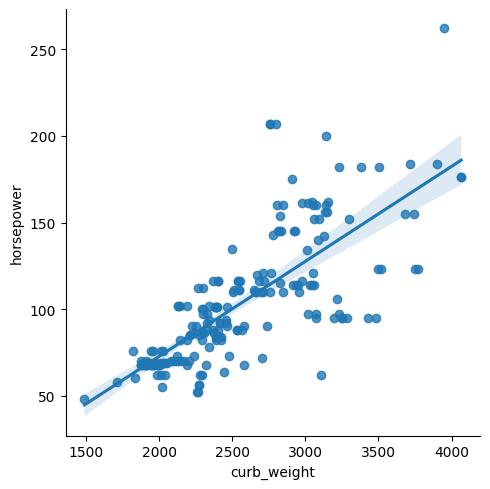

In [ ]:
sns.lmplot(data=df, x='curb_weight', y='horsepower');

**We can also check the relationship between two variables for different categories by specifying the *hue* parameter.**

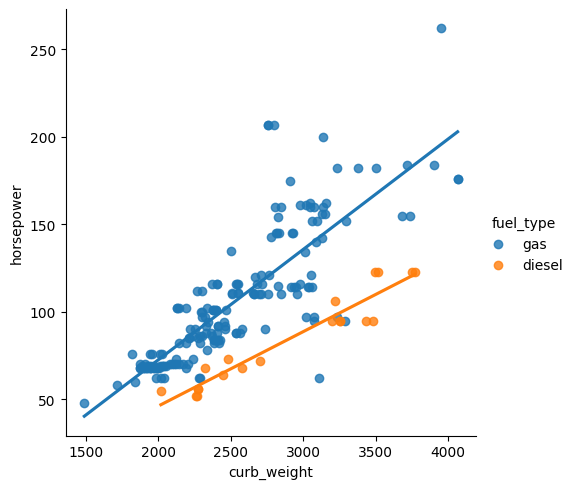

In [ ]:
sns.lmplot(data=df, x='curb_weight', y='horsepower', hue='fuel_type',ci=False);

**We can also disable the 95% confidence interval and just keep the regression model fit by setting the *ci* parameter to *False*.**

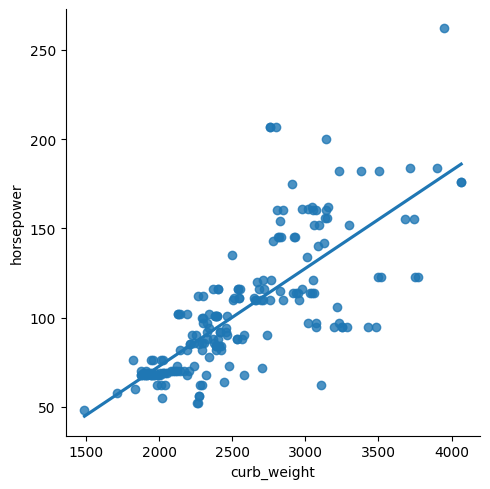

In [ ]:
sns.lmplot(data=df, x='curb_weight', y='horsepower', ci=False);

**We can also plot the levels of the third variable across different plots.**

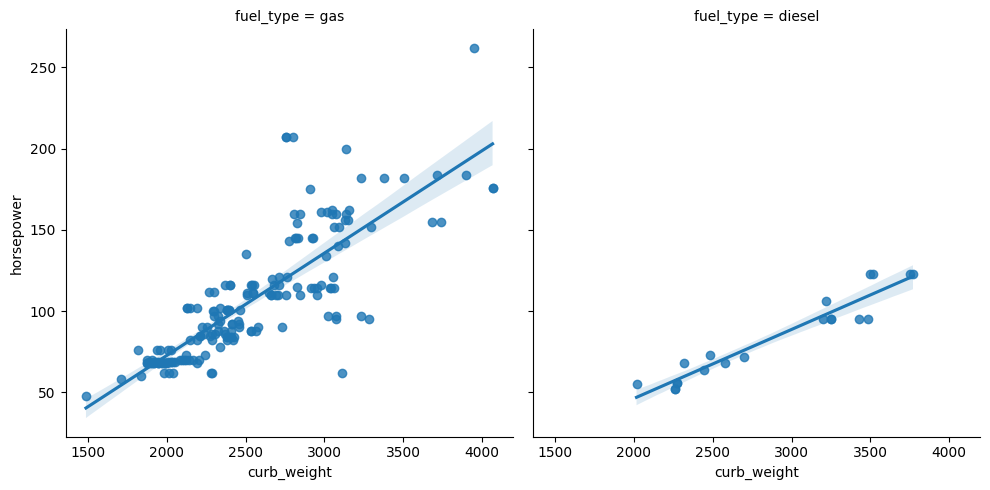

In [ ]:
sns.lmplot(data=df, x='curb_weight', y='horsepower', col='fuel_type');

**Let's check out the relationship between a few more variables using *lmplot()*.**

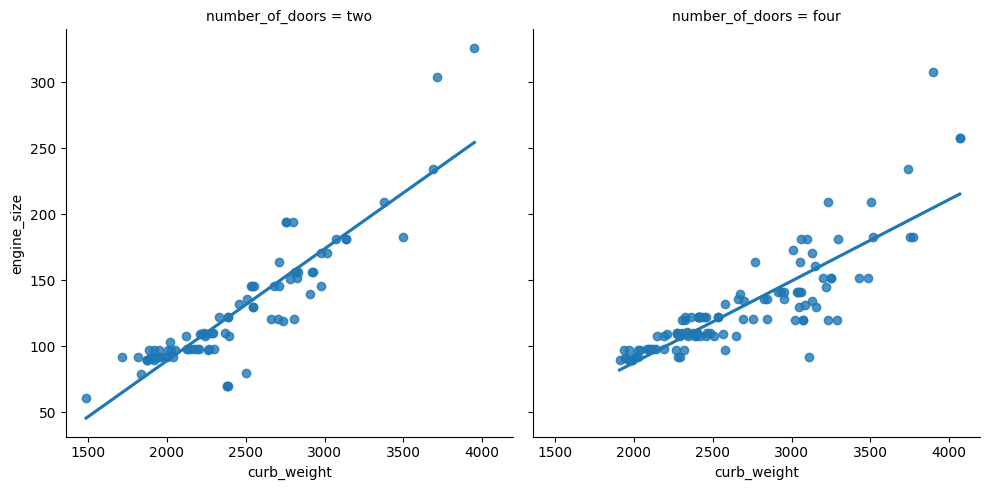

In [ ]:
sns.lmplot(data=df, x='curb_weight', y='engine_size', col='number_of_doors', ci=False)

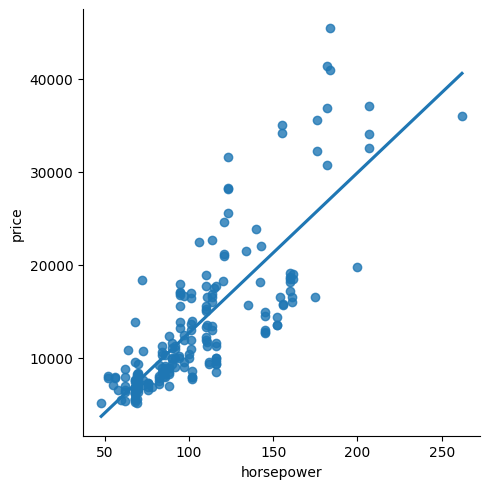

In [ ]:
sns.lmplot(data=df, x='horsepower', y='price', ci=False);

We have seen that histograms help us understand the distribution of individual variables and scatterplots help us identify the relationship between two variables. While we can view and analyze these plots separately, having them together in a single visualization would allow us to capture a lot more information in a concise manner. That's where a **jointplot** comes to our aid.

## Joint plot

* A jointplot helps to quickly visualize the bivariate and univariate profiles on the same plot.
* It comprises three plots - one displays the relationship between two variables while the other two show the individual distribution of each variable in the margins.
* The *jointplot()* function of seaborn can be used to create a jointplot.

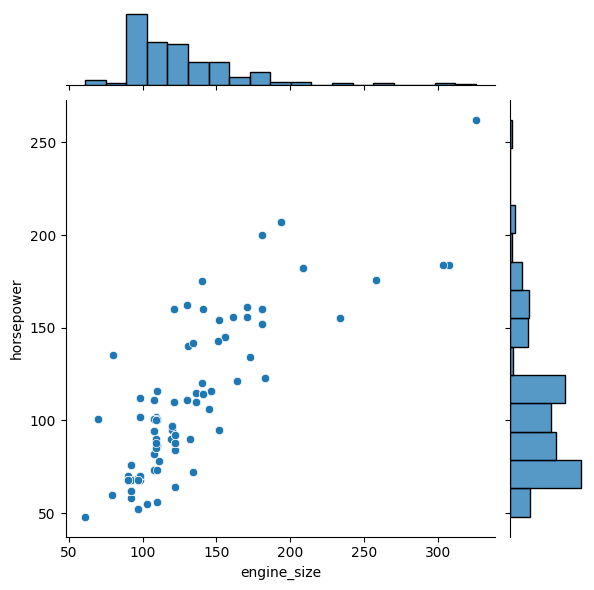

In [ ]:
sns.jointplot(data=df, x='engine_size', y='horsepower');

- By default, *jointplot()* creates a scatter plot to show the relationship between two variables and individual histograms are created in x and y axis margins for each of the variables.

One of the drawbacks of **scatterplots** is the overlapping of points. When we have large volumes of data to plot, the data points in the plot overlap with each other, making it difficult to interpret the data.

In such cases, we can *divide the entire plot into bins using different shapes (square, triangle, hexagon, etc.)* and then try to see the number of data points falling within each of the bins.

seaborn's *jointplot()* provides a '**hex**' kind to plot the data in above-mentioned way.

**We can create a hexbin plot by setting *kind="hex"*.**

- It actually splits the plotting window into several hexagons and the colour of each hexagon denotes the number of data points in it.

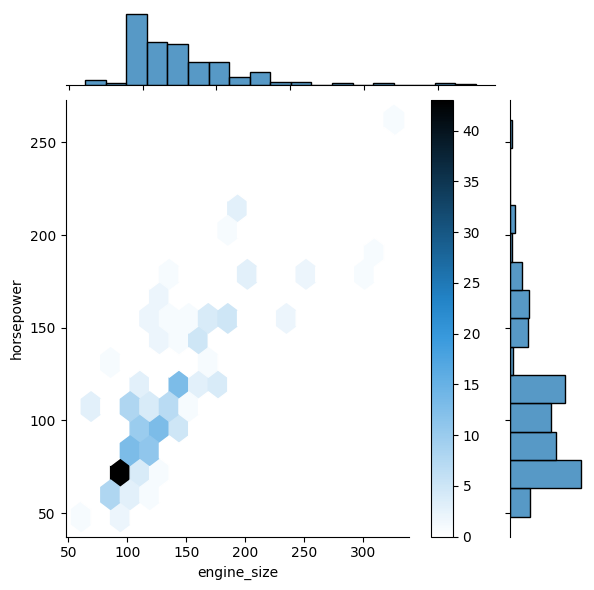

In [ ]:
sns.jointplot(data=df, x='engine_size', y='horsepower', kind="hex");
plt.colorbar(); # adds a separate axis indicating the color scale in this plot

**We can also create a kde plot by setting *kind="kde"*.**.

- A KDE jointplot also uses color to determine where observations are the most dense.
- It creates a continuous plot using probabilities of new data should be introduced.

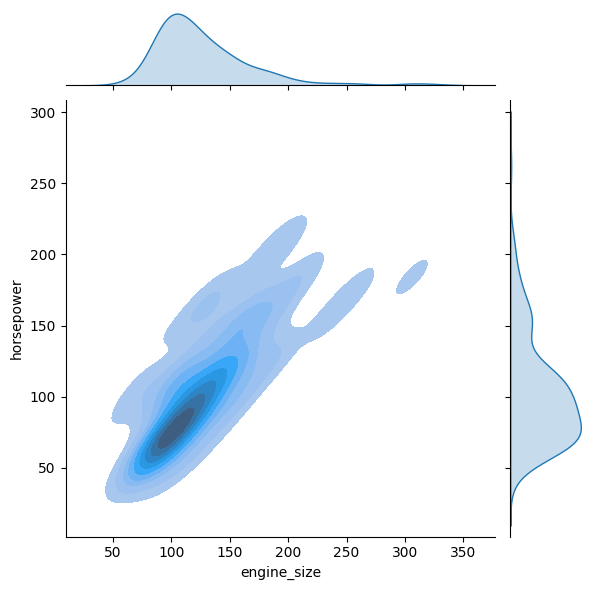

In [ ]:
sns.jointplot(data=df, x='engine_size', y='horsepower', kind="kde", fill=True);

**Let's check out the joint plots for a few more attributes in the data.**
- By using **kind = "reg"**, we can use the joint point to find the best line or curve that fits the plot.

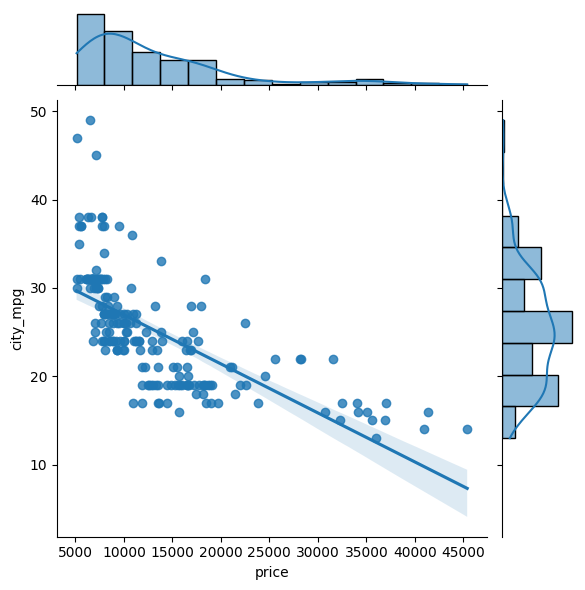

In [ ]:
sns.jointplot(data=df, x='price', y='city_mpg', kind="reg");

## Violin Plot

* A **violin plot** allows us to visualize the distribution of a numeric variable for several groups.
* It is similar to **boxplot** but with a rotated plot on each side, giving more information about the density estimate on the y-axis.
* The *violinplot()* function of seaborn can be used to make a violin plot.

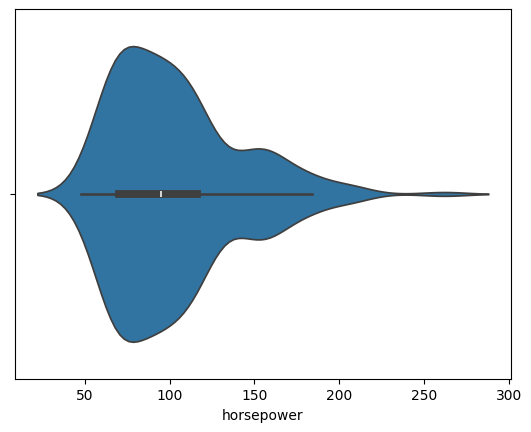

In [ ]:
sns.violinplot(data=df, x='horsepower');

- The white dot in the plot represents the **median**.
- The thick gray bar in the center represents the **interquartile range**.
- The wider section of the violin plot represents a higher probability and the skinnier sections represent a lower probability for the given value.

**We can get a vertical plot by setting *orient* parameter to *'v'* and assigning a numeric variable to the y-axis.**

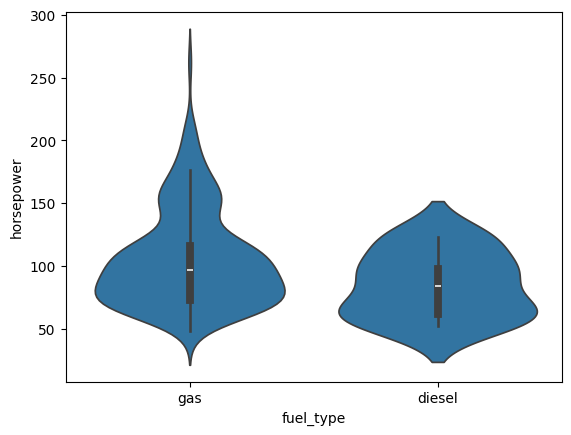

In [ ]:
sns.violinplot(data=df, x='fuel_type', y='horsepower', orient='v');

**Let's check out the violinplots for a few more attributes in the data.**

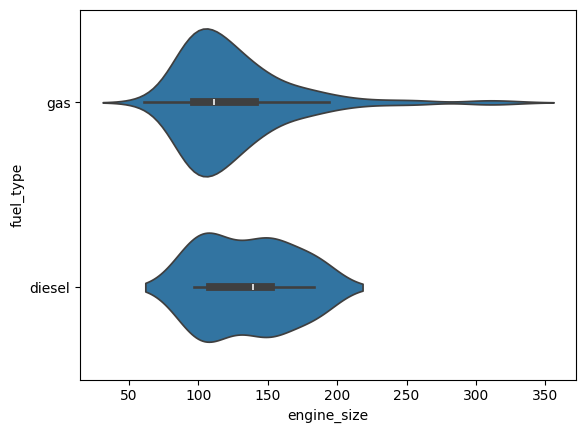

In [ ]:
sns.violinplot(data=df, x='engine_size', y='fuel_type');

**We can use the *palette* parameter to change the colour palette.**

- seaborn has six variations of it - deep, muted, pastel, bright, dark, colorblind.

/tmp/ipykernel_298/3581199320.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='body_style', y='engine_size', palette="bright");


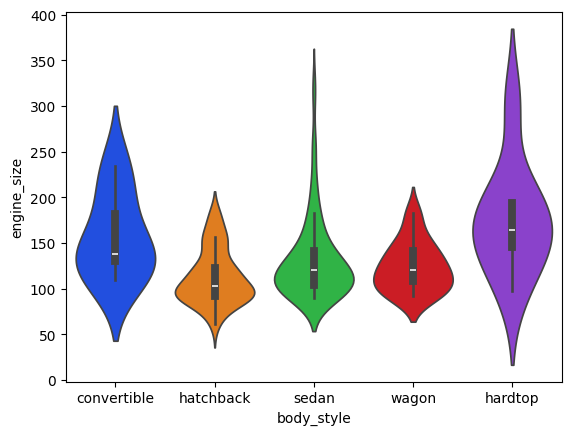

In [ ]:
sns.violinplot(data=df, x='body_style', y='engine_size', palette="bright");

/tmp/ipykernel_298/755128554.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='engine_location', y='price', palette="colorblind");


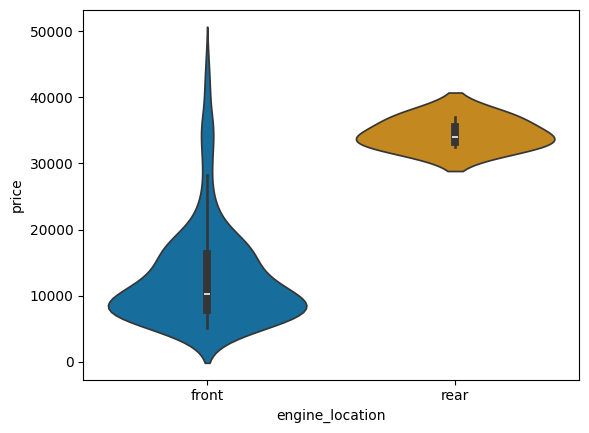

In [ ]:
sns.violinplot(data=df, x='engine_location', y='price', palette="colorblind");

Histograms and other distribution plots are typically preferred for larger data sets. When we have a small dataset and we want to visualize the frequency distribution, a **strip plot** can be used.

## Strip Plot

* A strip plot is basically a scatter plot that differentiates different categories.
* The *stripplot()* function of seaborn can be used to make a strip plot.

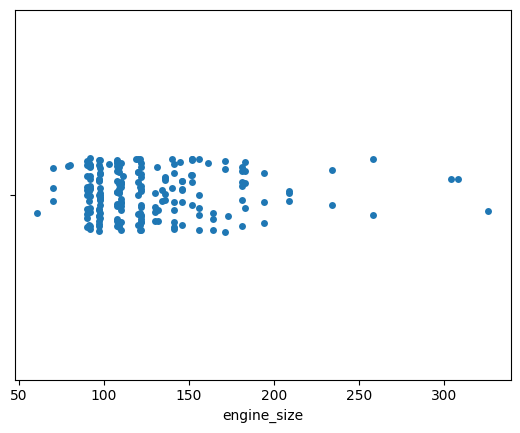

In [ ]:
sns.stripplot(data=df, x='engine_size');

Strip plots are considered a good alternative to a box plot or a violin plot for comparing data distributions when we have fewer data points.

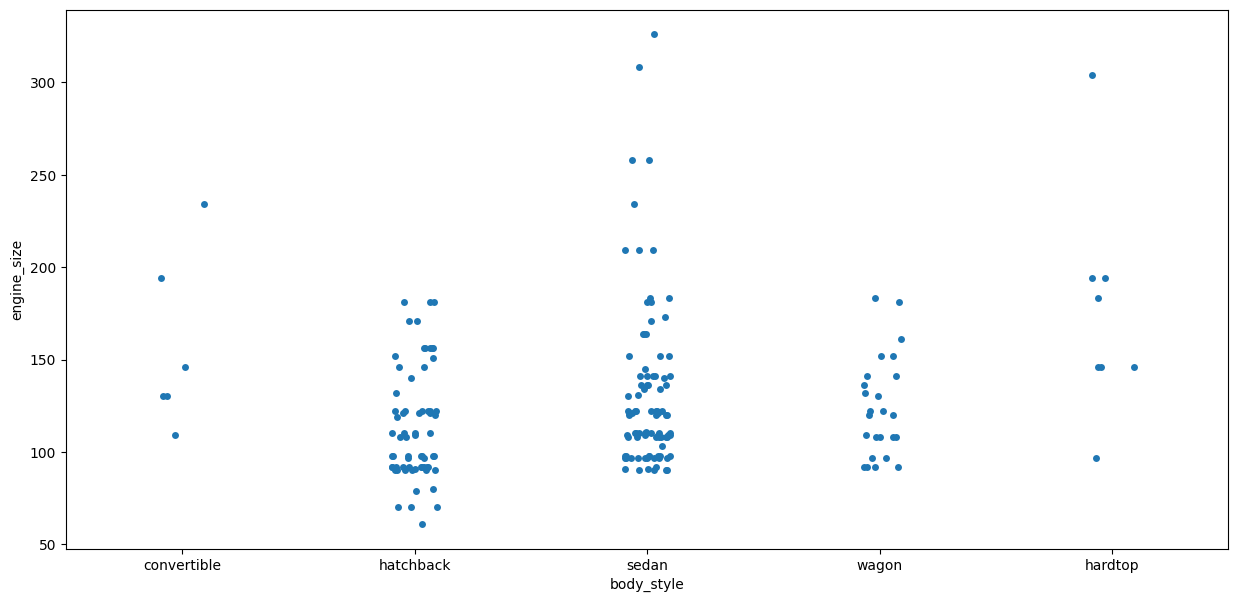

In [ ]:
plt.figure(figsize=(15,7))
sns.stripplot(data=df, x='body_style', y='engine_size');

**Strip plots are more useful when we add random noise called "jitter" to avoid overlapping of data points with same values.**

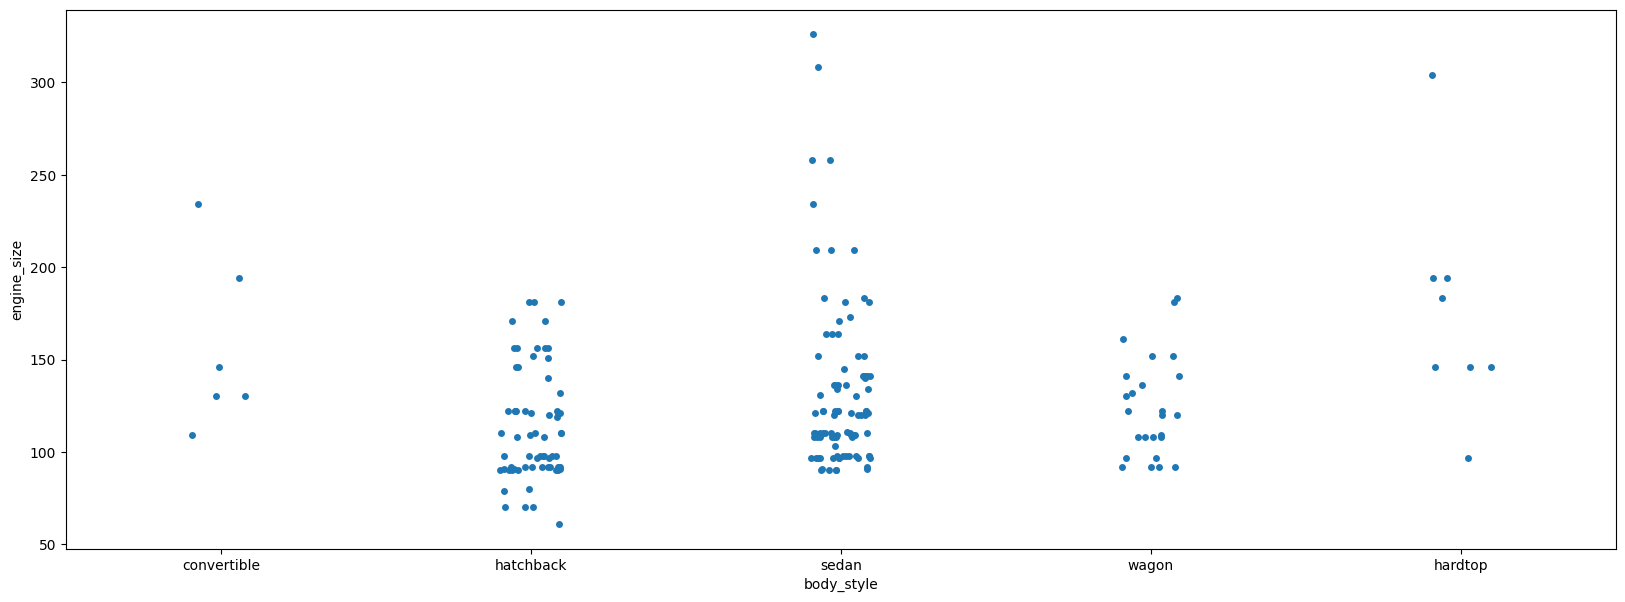

In [ ]:
plt.figure(figsize=(20,7))
sns.stripplot(data=df, x='body_style', y='engine_size', jitter=True);

**We can set the *hue* parameter to display observations for subgroups.**

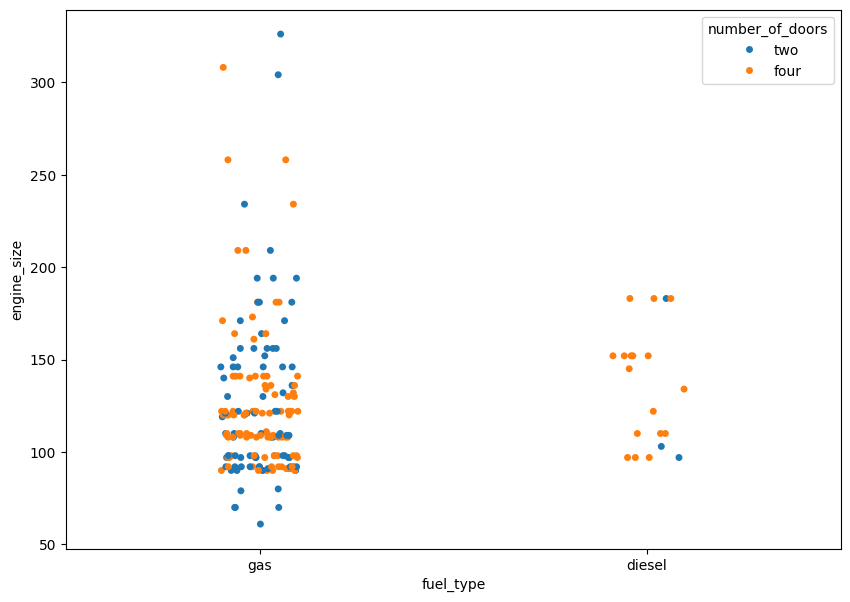

In [ ]:
plt.figure(figsize=(10,7))
sns.stripplot(data=df, x='fuel_type', y='engine_size', hue="number_of_doors", jitter=True);

**Let's check out the strip plots for a few more attributes in the data.**

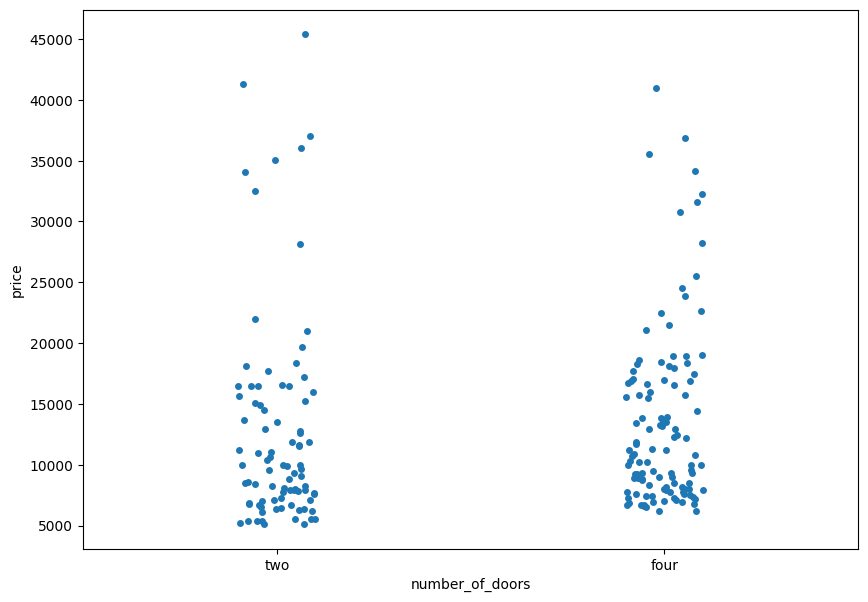

In [ ]:
plt.figure(figsize=(10,7))
sns.stripplot(data=df, x='number_of_doors', y='price',jitter=True);

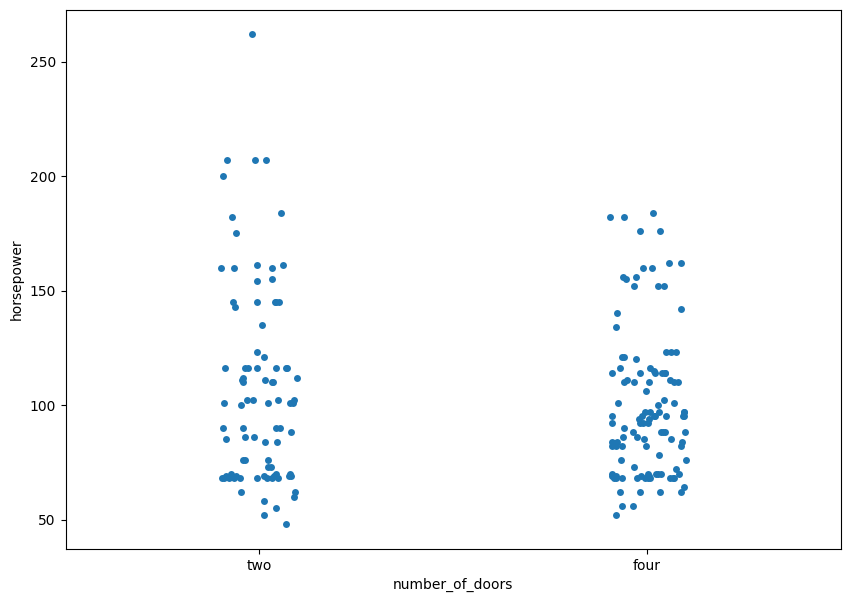

In [ ]:
plt.figure(figsize=(10,7))
sns.stripplot(data=df, x='number_of_doors', y='horsepower', jitter=True);

In a strip plot, dots are randomly arranged in vertical direction, which means we can not use the width to estimate distribution. This can be easily done by **swarm plots**.

## Swarm Plot

* A **swarm plot** is very similar to the strip plot, but it avoids the overlapping of points.
* The *swarmplot( )* function of seaborn can be used to create such a graph for categorical values.

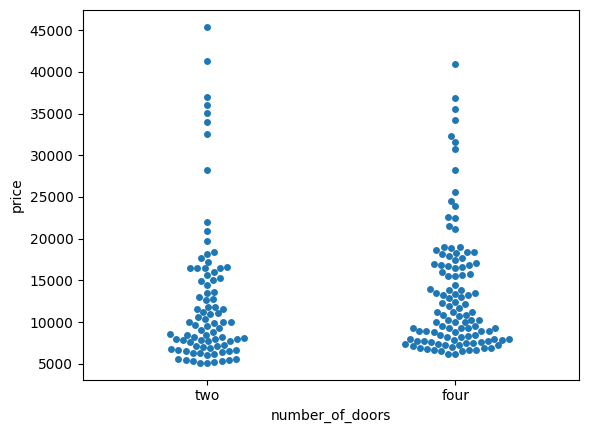

In [ ]:
sns.swarmplot(data=df, x='number_of_doors', y='price');

- In a swarm plot, dots are arranged in vertical columns.
- So, we can estimate the distribution of our data by looking at the width of the plot.

**We can add the *hue* parameter to *swarmplot()* and separate the categories.**

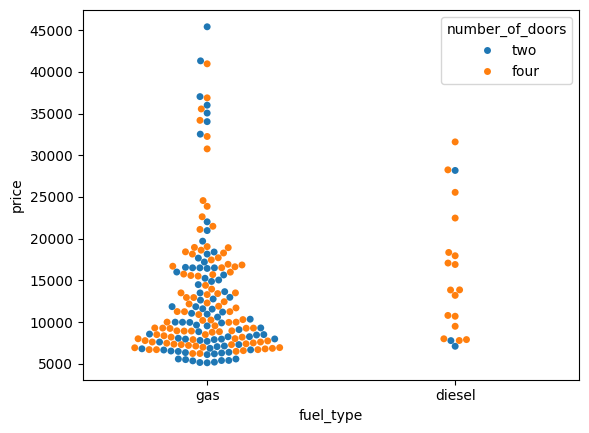

In [ ]:
sns.swarmplot(data=df, x='fuel_type', y='price', hue='number_of_doors');

**We can split the two products setting the *dodge* argument to *True*.**

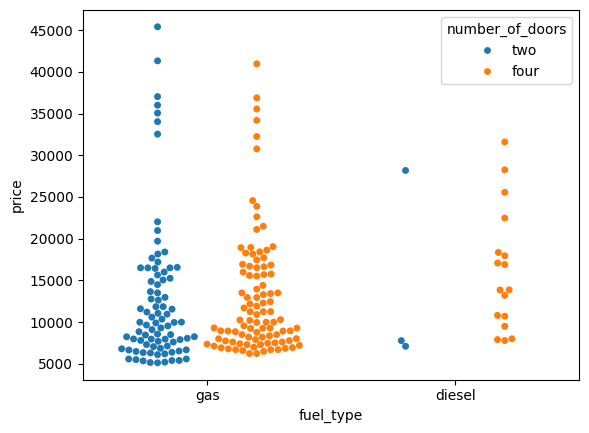

In [ ]:
sns.swarmplot(data=df, x='fuel_type', y='price', hue='number_of_doors', dodge=True);

## Catplot

* The *catplot()* function provides a new framework giving access to several types of plots that show relationship between numerical variable and one or more categorical variables.
* Catplots supports 8 different plots including *stripplot()*, *swarmplot()*, *boxplot()* and more, with the default kind being 'strip'.

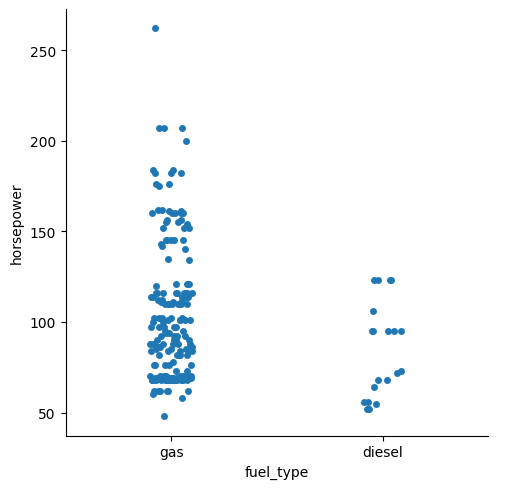

In [ ]:
sns.catplot(data=df, x='fuel_type', y='horsepower');

**We can set *kind='point'* to create a pointplot using the *catplot()* function.**

- A pointplot helps us to see how the main relationship is changing as a function of the second variable.

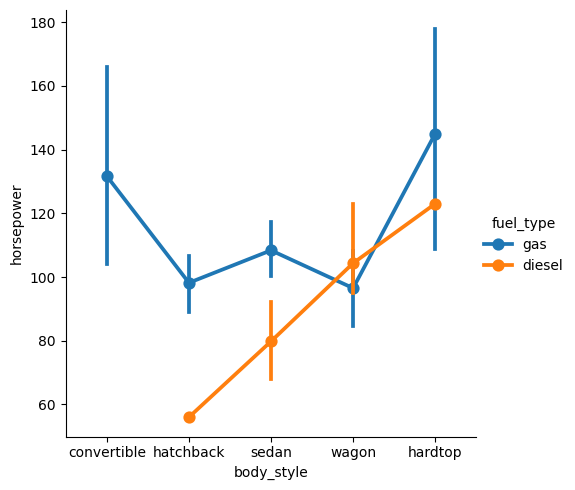

In [ ]:
sns.catplot(data=df, x='body_style', y='horsepower', hue='fuel_type', kind='point');

**Catplot is very useful to draw categorical plots onto a FacetGrid by assigning a third variable to the *col* parameter.**

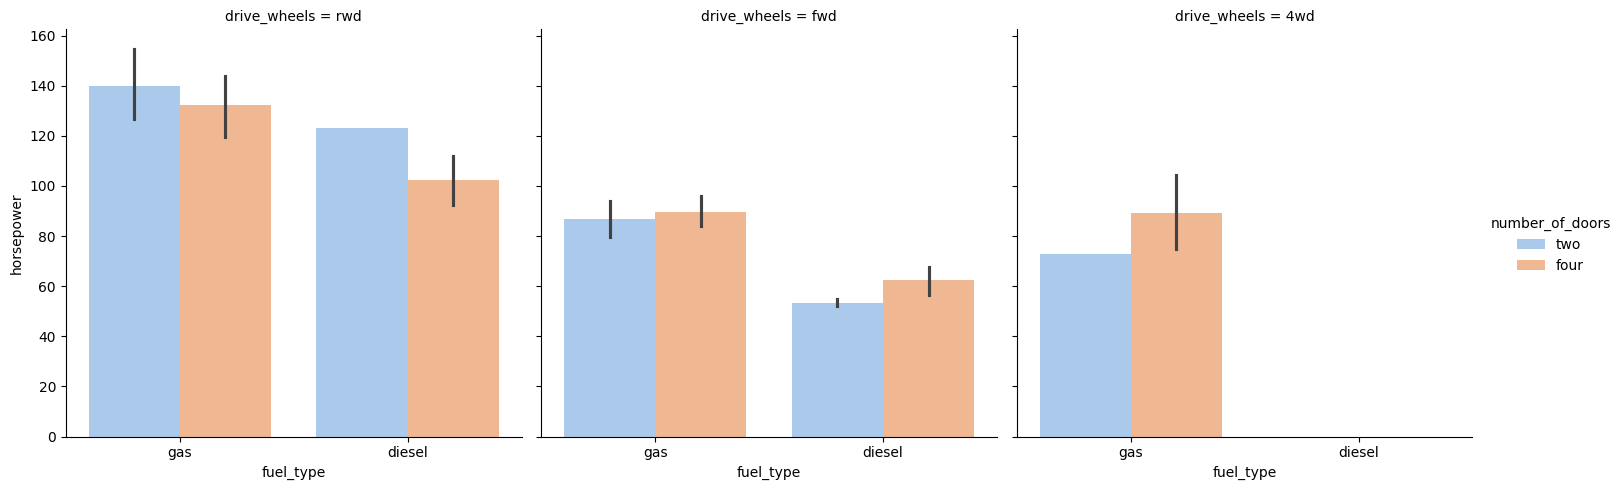

In [ ]:
sns.catplot(data=df, x="fuel_type", y="horsepower", hue="number_of_doors", col="drive_wheels", kind='bar', palette='pastel');

**Let's check out the *catplot()* function for a few more attributes in the data.**

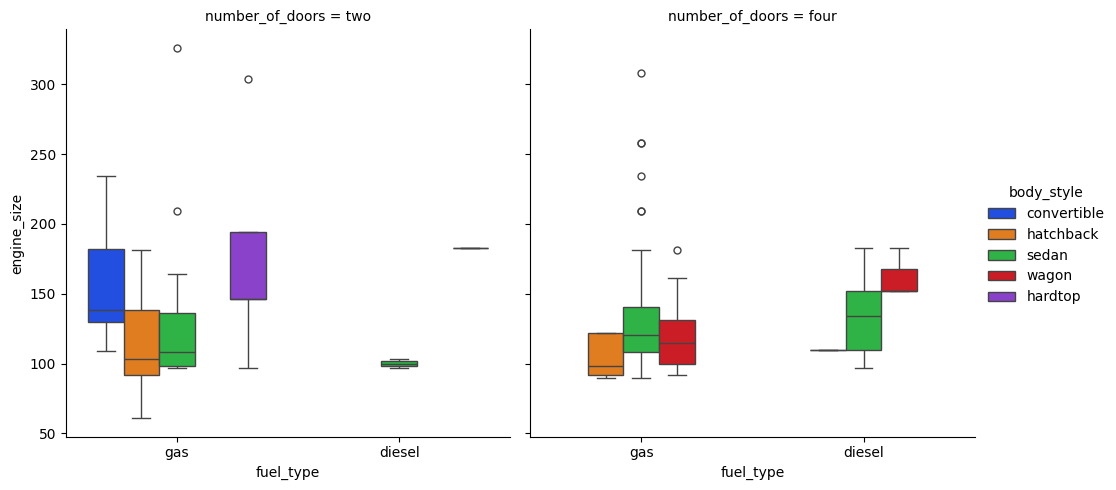

In [ ]:
sns.catplot(data=df, x="fuel_type", y="engine_size", hue="body_style", col="number_of_doors", kind='box', palette='bright');

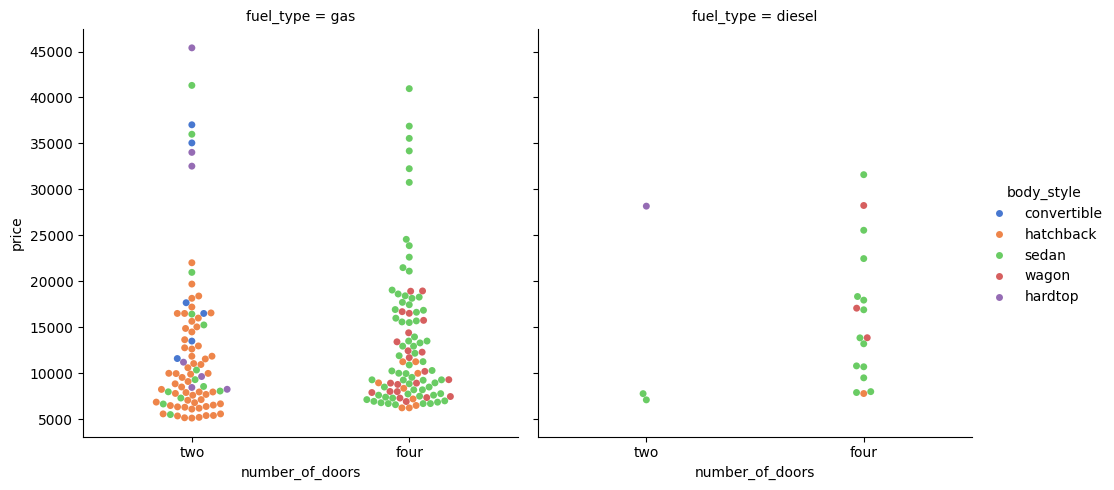

In [ ]:
sns.catplot(data=df, x="number_of_doors", y="price", hue="body_style", col="fuel_type", kind='swarm', palette='muted');

## Plotly

- **Plotly** is an open-source Python graphing library for building beautiful and interactive visualizations.

In [ ]:
# let's start by installing plotly
#!pip install plotly

In [ ]:
# importing plotly
import plotly.express as px

### Histogram

In [ ]:
his = px.histogram(df, x="price")
his.show()

### Bar Plot

In [ ]:
bar = px.bar(df, x='peak_rpm', y='horsepower')
bar.show()

### Scatter Plot

In [ ]:
scat = px.scatter(df, x='price', y='engine_size')
scat.show()

### Boxplot with underlying data

In [ ]:
fig = px.box(df, x="fuel_type", y="horsepower", points="all")
fig.show()

### 3D Scatter Plot

In [ ]:
fig_3d = px.scatter_3d(df, x='fuel_type', y='horsepower', z='price', color='horsepower')
fig_3d.show()

In [ ]:
# to save the output to an HTML file
fig_3d.write_html("scatter_3d.html")

***

## Customizing plots

- In this section we will see how we can customize  plots by using different matplotlib and seaborn functions.

To change the axis scales of a plot:

```
    plt.xlim(left, right)   # here left and right indicates the min and the max limits of  x-axis respectively
    plt.ylim(bottom, top)   # here bottom and top indicates the min and the max limits of  y-axis respectively
```

To change the plot title and axis labels:

```
    plt.title()
    plt.xlabel()   # for x_axis labels
    plt.ylabel()   # for y_axis labels
```

To show the grid lines of a plot:

```
    sns.set(style="darkgrid")
    sns.set(style="whitegrid")
    sns.set(style="white")
```

To hide the axes of a plot:

```
    plt.axis('off')   # it will hide both the x-axis and y-axis
```

To customize labels of the plot legend:

```
    ax.legend([])   # takes list of the legend values
```

To change the position of the plot legend:

```
    plt.legend(loc=___)
```

The following values can be added to *loc* to change the location of the legend:
- 'upper left', 'upper right', 'lower left', 'lower right', 'center', 'best', [etc.](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html)

***